# Cuaderno 02: Creación de Arquetipos de Egresados 🧑‍🔬

## 1. Introducción y Configuración

**Objetivo:** Este cuaderno utiliza el dataset analítico (`df_analitico`) generado en el Cuaderno 01 para aplicar algoritmos de clustering. El propósito es segmentar a la población de egresados en grupos distintos y homogéneos, conocidos como **"arquetipos"** o **"perfiles de impacto"**.

**Librerías:**
* `pandas` y `numpy`: Para la manipulación de datos.
* `sklearn.preprocessing`: Para escalar los datos antes del clustering.
* `sklearn.cluster`: Para ejecutar el algoritmo K-Means.
* `matplotlib` y `seaborn`: Para visualizaciones.

**Detalle del Código:** El primer paso es cargar el `df_analitico.csv` que guardamos al final del cuaderno anterior.

In [1]:
# 1. LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Configuraciones de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

# 2. CARGA DEL DATASET ANALÍTICO
# Asumimos que el archivo fue guardado en la carpeta 'datos'
try:
    data_path = '../datos/df_analitico.csv'
    df_analitico = pd.read_csv(data_path, index_col=0) # Usamos la primera columna como índice
    print("Dataset analítico cargado exitosamente.")
    display(df_analitico.head())
except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{data_path}'.")
    print("Asegúrate de haber guardado el 'df_analitico' del Cuaderno 01 en la carpeta 'datos'.")

Dataset analítico cargado exitosamente.


,f_transversal_general,f_disc_competencias,f_disc_valoracion,f_disc_logros,c3_18_ingresos_superiores_estudio,c3_19_1_mejora_vivienda,f_calidad_vida_general,sede,programa_academico,ano_graduacion,c1_1_laborando_actualmente
0,0.150675,0.433642,0.948576,-0.445924,0,1,-1.020553,Seccional Bucaramanga,INGENIERÍA INDUSTRIAL,2021,Si
1,0.036455,0.359566,0.322907,-0.345887,1,0,0.662546,Seccional Bucaramanga,QUÍMICA AMBIENTAL,2018,Si
2,-0.085889,0.458820,0.212146,-0.510461,1,1,-0.691597,Seccional Bucaramanga,ESPECIALIZACIÓN EN CONTRATACIÓN ESTATAL,2024,No
3,0.036455,0.164578,0.227694,0.303290,0,0,-0.691597,Seccional Bucaramanga,ESPECIALIZACIÓN EN CONTRATACIÓN ESTATAL,2019,No
4,-0.707985,-0.134703,-0.580903,-0.512669,1,0,0.735561,Seccional Bucaramanga,ESPECIALIZACIÓN EN FINANZAS PÚBLICAS,2024,No


## 2. Preparación de Datos para Clustering

**Objetivo:** Antes de aplicar un algoritmo como K-Means, es fundamental preparar los datos. Esto implica dos pasos:
1.  **Selección de Variables:** Elegir únicamente las variables numéricas que definen el perfil de un egresado (nuestros puntajes factoriales e indicadores).
2.  **Escalado de Datos:** Asegurarse de que todas las variables tengan una escala similar para que ninguna domine el análisis por tener un rango de valores más amplio.

**Detalle del Código:** Usaremos `StandardScaler` de Scikit-learn para estandarizar nuestras variables, dándoles una media de 0 y una desviación estándar de 1.

In [2]:
# 1. SELECCIÓN DE VARIABLES PARA EL CLUSTERING
# Seleccionamos los 5 puntajes factoriales y los 2 indicadores de movilidad
features_para_cluster = [
    'f_transversal_general',
    'f_disc_competencias',
    'f_disc_valoracion',
    'f_disc_logros',
    'f_calidad_vida_general',
    'c3_18_ingresos_superiores_estudio',
    'c3_19_1_mejora_vivienda'
]

# Creamos un nuevo dataframe solo con estas variables
df_cluster = df_analitico[features_para_cluster].dropna()

print(f"Se usarán {len(df_cluster)} registros completos para el clustering.")
print("Variables seleccionadas:")
print(features_para_cluster)

# 2. ESCALADO DE DATOS
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print("\nLos datos han sido escalados. Dimensiones de la matriz de análisis:", X_scaled.shape)

Se usarán 959 registros completos para el clustering.
Variables seleccionadas:
['f_transversal_general', 'f_disc_competencias', 'f_disc_valoracion', 'f_disc_logros', 'f_calidad_vida_general', 'c3_18_ingresos_superiores_estudio', 'c3_19_1_mejora_vivienda']

Los datos han sido escalados. Dimensiones de la matriz de análisis: (959, 7)


## 3. Determinación del Número Óptimo de Clústeres (Análisis Comparativo de Algoritmos)

**Objetivo:** Para aumentar la confianza en nuestra elección del número de clústeres (`k`), no nos basaremos en un solo algoritmo. En su lugar, compararemos los resultados de tres métodos con fundamentos distintos:

1.  **K-Means:** Un método basado en centroides, evaluado con múltiples métricas de calidad (Silueta, etc.).
2.  **Clustering Jerárquico Aglomerativo:** Un método que construye una jerarquía de clústeres. Lo visualizaremos con un **dendrograma** para identificar visualmente la estructura de agrupación.
3.  **Modelos de Mezcla Gaussiana (GMM):** Un modelo probabilístico que asume que los datos provienen de una mezcla de distribuciones gaussianas. Usaremos el **Criterio de Información Bayesiano (BIC)** para evaluar el ajuste del modelo, donde un valor más bajo es mejor.

Buscamos un **consenso** entre los tres métodos para seleccionar el `k` final.

---
### 3.1. Evaluación con K-Means (Análisis Multimétrico)

**Detalle:** Este es el análisis que ya realizamos. Ejecutamos K-Means para un rango de `k` y evaluamos cada solución con tres métricas de calidad para buscar un punto óptimo.

Calculando métricas de calidad para K-Means...
Cálculo para K-Means completado.


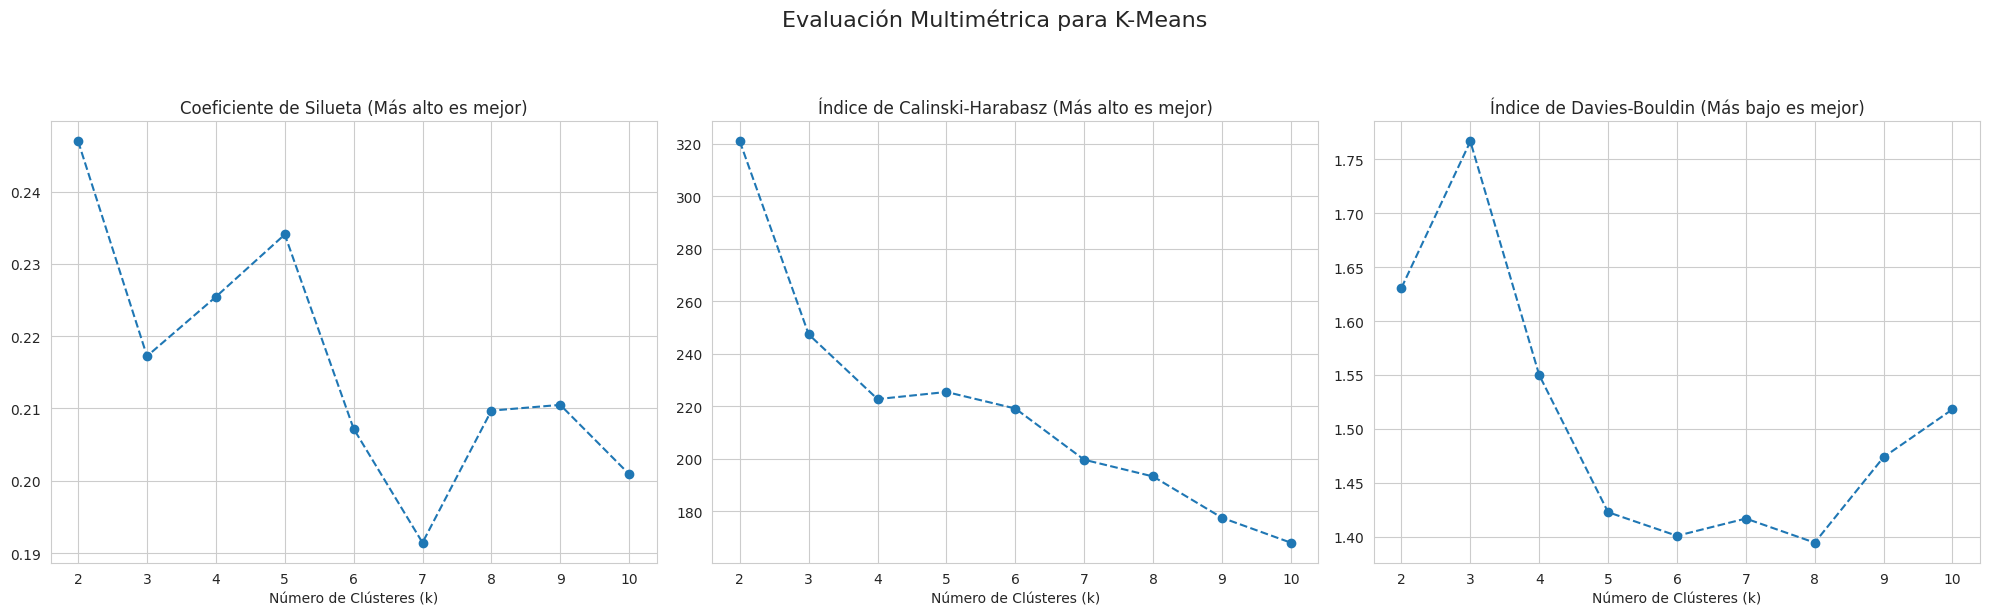

In [7]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans

# Asumimos que X_scaled del paso anterior ya existe.
k_range = range(2, 11)
silhouette_scores = []
calinski_scores = []
davies_scores = []

print("Calculando métricas de calidad para K-Means...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(X_scaled, labels))
    davies_scores.append(davies_bouldin_score(X_scaled, labels))
print("Cálculo para K-Means completado.")

# --- Visualización de los resultados de K-Means ---
fig, axs = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Evaluación Multimétrica para K-Means', fontsize=16, y=1.02)
axs[0].plot(k_range, silhouette_scores, marker='o', linestyle='--')
axs[0].set_title('Coeficiente de Silueta (Más alto es mejor)')
axs[0].set_xlabel('Número de Clústeres (k)')
axs[1].plot(k_range, calinski_scores, marker='o', linestyle='--')
axs[1].set_title('Índice de Calinski-Harabasz (Más alto es mejor)')
axs[1].set_xlabel('Número de Clústeres (k)')
axs[2].plot(k_range, davies_scores, marker='o', linestyle='--')
axs[2].set_title('Índice de Davies-Bouldin (Más bajo es mejor)')
axs[2].set_xlabel('Número de Clústeres (k)')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

---
### 3.2. Evaluación con Clustering Jerárquico (Dendrograma)

**Detalle:** Este método no requiere pre-especificar `k`. En su lugar, construye un árbol de agrupaciones (dendrograma). Analizamos visualmente el dendrograma para decidir dónde "cortar" el árbol, lo que define el número de clústeres. Buscamos cortar en el punto donde las líneas verticales son más largas, lo que representa la mayor distancia entre las fusiones de clústeres.

Calculando el clustering jerárquico y generando el dendrograma...


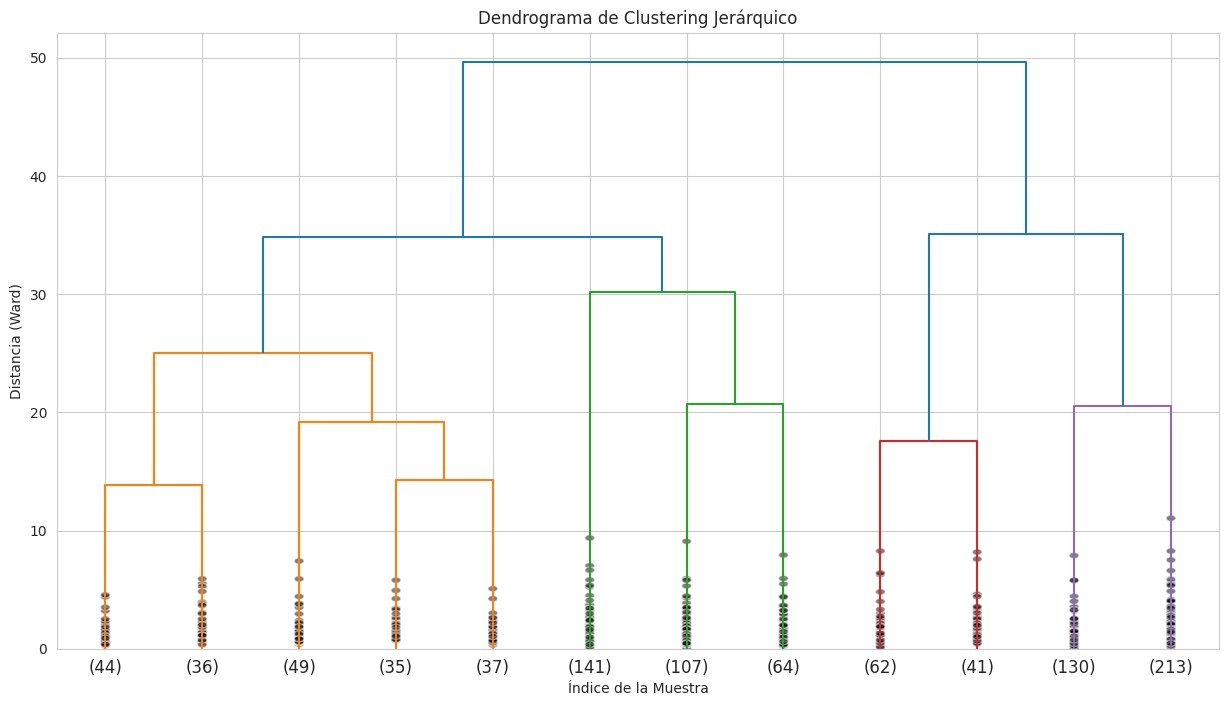

In [8]:
from scipy.cluster.hierarchy import dendrogram, linkage

print("Calculando el clustering jerárquico y generando el dendrograma...")

# Usamos el método 'ward', que minimiza la varianza dentro de los clústeres
Z = linkage(X_scaled, method='ward')

# Graficar el dendrograma
plt.figure(figsize=(15, 8))
plt.title('Dendrograma de Clustering Jerárquico')
plt.xlabel('Índice de la Muestra')
plt.ylabel('Distancia (Ward)')
# 'truncate_mode' y 'p' ayudan a que el gráfico sea legible con muchos puntos
dendrogram(Z,
           truncate_mode='lastp', # Muestra solo los últimos 'p' clústeres fusionados
           p=12,                # Número de clústeres finales a mostrar
           show_leaf_counts=True,
           show_contracted=True)
plt.show()

---
### 3.3. Evaluación con Modelos de Mezcla Gaussiana (GMM)

**Detalle:** GMM es un algoritmo probabilístico. Para encontrar el número óptimo de clústeres (componentes), ajustamos el modelo con un rango de `k` y calculamos el **Criterio de Información Bayesiano (BIC)** para cada uno. El BIC penaliza la complejidad del modelo, ayudando a evitar el sobreajuste. Buscaremos el valor de `k` que corresponda al **BIC más bajo**.

Calculando el BIC para diferentes números de componentes GMM...
Cálculo para GMM completado.


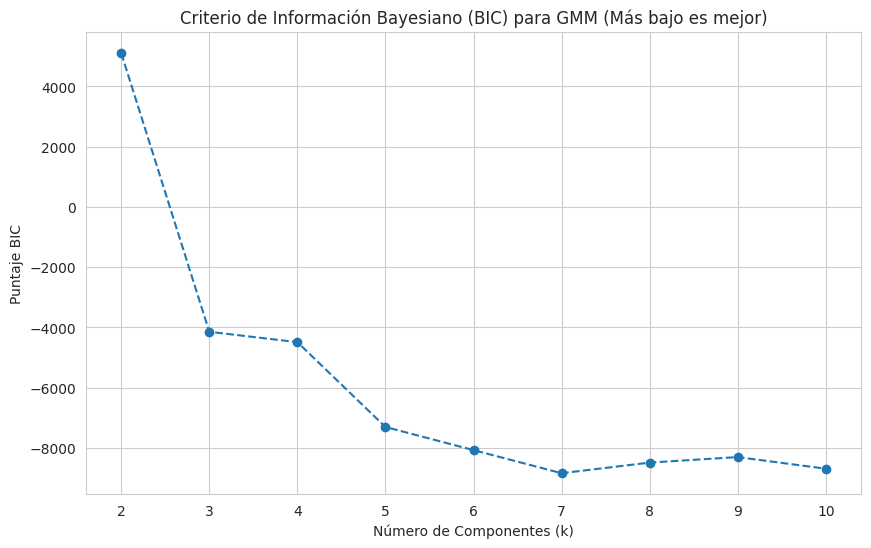

In [9]:
from sklearn.mixture import GaussianMixture

bic_scores = []
k_range = range(2, 11)

print("Calculando el BIC para diferentes números de componentes GMM...")
for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))

print("Cálculo para GMM completado.")

# Graficar los puntajes BIC
plt.figure(figsize=(10, 6))
plt.plot(k_range, bic_scores, marker='o', linestyle='--')
plt.xlabel('Número de Componentes (k)')
plt.ylabel('Puntaje BIC')
plt.title('Criterio de Información Bayesiano (BIC) para GMM (Más bajo es mejor)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

### Análisis de los Gráficos

Ahora, para elegir el número óptimo de clústeres (`k`), buscamos un **consenso** entre las tres métricas:
* En el **Coeficiente de Silueta**, buscamos el pico más alto.
* En el **Índice de Calinski-Harabasz**, también buscamos el pico más alto.
* En el **Índice de Davies-Bouldin**, buscamos el punto más bajo.

El valor de `k` donde estas métricas coincidan o muestren un comportamiento óptimo será nuestra elección para crear los arquetipos finales.

Iniciando comparación sistemática de algoritmos de clustering...
Evaluando algoritmo: KMeans...
Evaluando algoritmo: Agglomerative...
Evaluando algoritmo: GMM...
Cálculo completado.


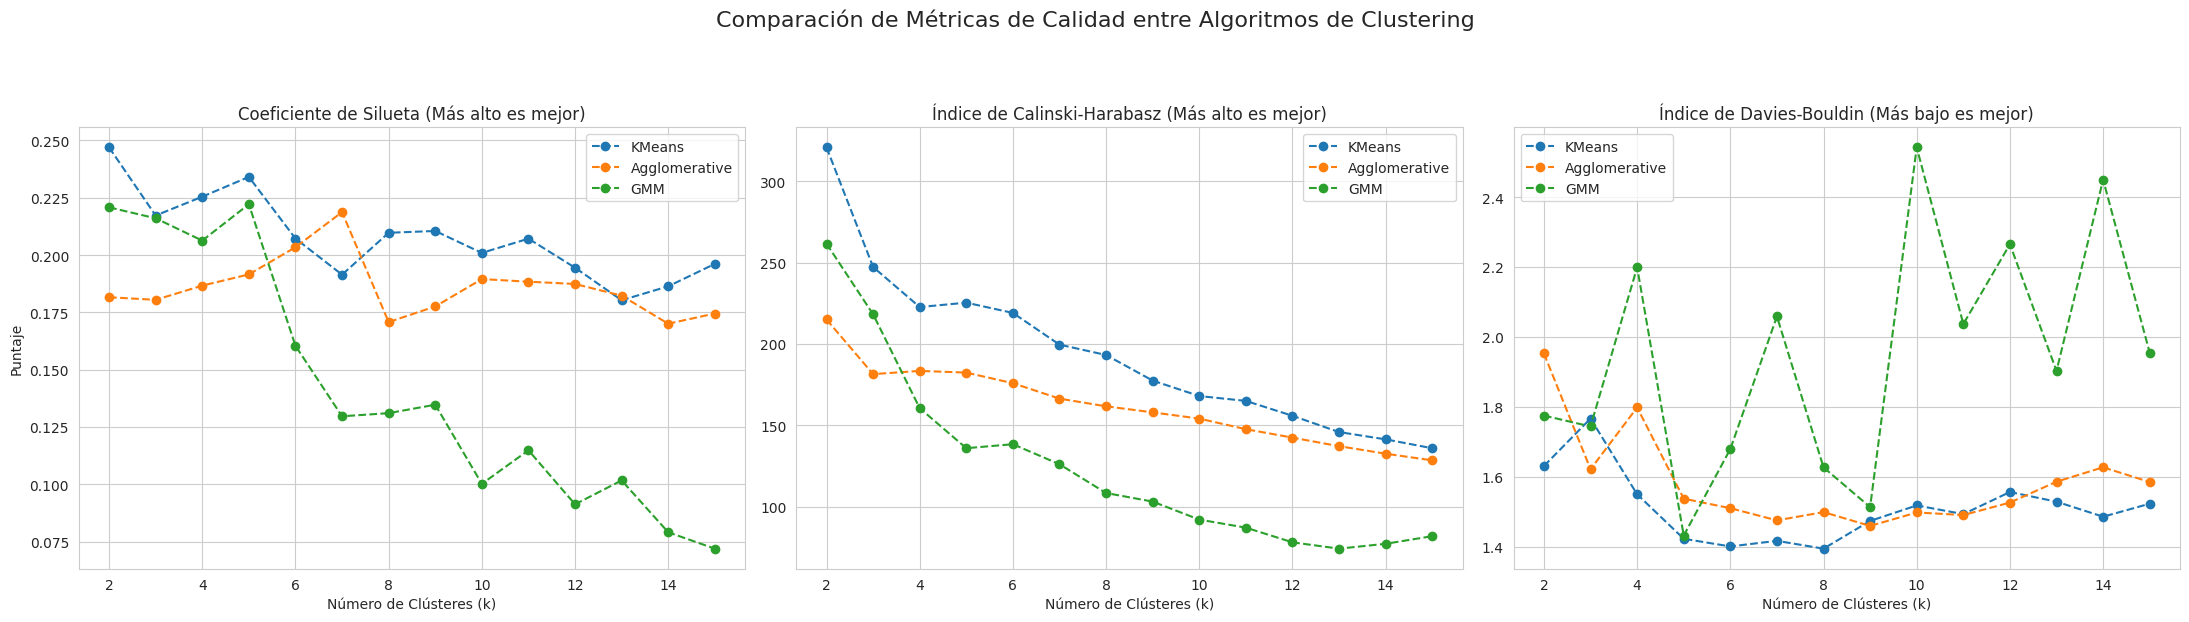

In [11]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# --- CONFIGURACIÓN DEL ANÁLISIS ---

# Asumimos que X_scaled del paso anterior ya existe.
k_range = range(2, 16)

# Diccionario para almacenar los resultados: metrica -> algoritmo -> [scores]
results = {
    'silhouette': {},
    'calinski': {},
    'davies': {}
}

# Lista de algoritmos a probar
algorithms = {
    'KMeans': KMeans,
    'Agglomerative': AgglomerativeClustering,
    'GMM': GaussianMixture
}

print("Iniciando comparación sistemática de algoritmos de clustering...")

# --- CICLO ANIDADO PARA LA EVALUACIÓN ---
for name, Algorithm in algorithms.items():
    print(f"Evaluando algoritmo: {name}...")
    
    # Listas para los scores de este algoritmo
    silhouette_scores = []
    calinski_scores = []
    davies_scores = []
    
    for k in k_range:
        # Inicializar el modelo con el número actual de clústeres/componentes
        if name == 'GMM':
            model = Algorithm(n_components=k, random_state=42, n_init=10)
        else: # Para KMeans y Agglomerative
            model_params = {'n_clusters': k}
            if name == 'KMeans':
                model_params['random_state'] = 42
                model_params['n_init'] = 'auto'
            model = Algorithm(**model_params)
            
        # Ajustar el modelo y obtener las etiquetas
        labels = model.fit_predict(X_scaled)
        
        # Calcular y guardar las métricas
        silhouette_scores.append(silhouette_score(X_scaled, labels))
        calinski_scores.append(calinski_harabasz_score(X_scaled, labels))
        davies_scores.append(davies_bouldin_score(X_scaled, labels))
        
    # Guardar los resultados para este algoritmo
    results['silhouette'][name] = silhouette_scores
    results['calinski'][name] = calinski_scores
    results['davies'][name] = davies_scores

print("Cálculo completado.")

# --- VISUALIZACIÓN COMPARATIVA DE RESULTADOS ---
fig, axs = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Comparación de Métricas de Calidad entre Algoritmos de Clustering', fontsize=16, y=1.03)

# Gráfico 1: Coeficiente de Silueta
for name, scores in results['silhouette'].items():
    axs[0].plot(k_range, scores, marker='o', linestyle='--', label=name)
axs[0].set_title('Coeficiente de Silueta (Más alto es mejor)')
axs[0].set_xlabel('Número de Clústeres (k)')
axs[0].set_ylabel('Puntaje')
axs[0].legend()
axs[0].grid(True)

# Gráfico 2: Índice de Calinski-Harabasz
for name, scores in results['calinski'].items():
    axs[1].plot(k_range, scores, marker='o', linestyle='--', label=name)
axs[1].set_title('Índice de Calinski-Harabasz (Más alto es mejor)')
axs[1].set_xlabel('Número de Clústeres (k)')
axs[1].legend()
axs[1].grid(True)

# Gráfico 3: Índice de Davies-Bouldin
for name, scores in results['davies'].items():
    axs[2].plot(k_range, scores, marker='o', linestyle='--', label=name)
axs[2].set_title('Índice de Davies-Bouldin (Más bajo es mejor)')
axs[2].set_xlabel('Número de Clústeres (k)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Análisis de Resultados y Elección del Modelo de Clustering

El análisis comparativo de los tres algoritmos a través de las tres métricas de calidad nos proporciona la evidencia necesaria para seleccionar de forma robusta tanto el número de clústeres (`k`) como el algoritmo más adecuado para segmentar a la población de egresados.

### Evaluación por Métrica

1.  **Coeficiente de Silueta (Más alto es mejor):**
    * **KMeans** muestra su puntaje más alto en `k=2` (0.247), con un segundo pico notable en `k=5` (0.234).
    * Los otros dos algoritmos obtienen puntajes consistentemente más bajos que KMeans. GMM también muestra un pico relativo en `k=5` (0.222).
    * **Conclusión de Silueta:** Sugiere que `k=2` o `k=5` son las soluciones más fuertes, con una clara ventaja para el algoritmo KMeans.

2.  **Índice de Calinski-Harabasz (Más alto es mejor):**
    * Esta métrica muestra una preferencia muy fuerte y unánime por una solución de **`k=2`**. Para los tres algoritmos, el puntaje es máximamente alto en `k=2` y desciende drásticamente a medida que `k` aumenta.
    * **Conclusión de Calinski-Harabasz:** Apunta de forma contundente a una segmentación en dos grandes grupos.

3.  **Índice de Davies-Bouldin (Más bajo es mejor):**
    * Esta métrica es menos concluyente, pero tiende a favorecer un número mayor de clústeres.
    * **KMeans** obtiene sus mejores (más bajos) puntajes en el rango de `k=5` a `k=8`.
    * **GMM** también muestra su mejor rendimiento en `k=5`.
    * **Conclusión de Davies-Bouldin:** Sugiere que una solución con más de dos clústeres, posiblemente `k=5`, es preferible.

### Discusión y Decisión Final

El análisis presenta dos escenarios principales:
* Una solución estadísticamente simple y robusta con **`k=2`**, fuertemente respaldada por el índice de Calinski-Harabasz y parcialmente por la Silueta. Esto dividiría a los egresados en dos grandes grupos (ej. "perfil de alto impacto" vs. "perfil de bajo impacto").
* Una solución más matizada y granular con **`k=5`**, que, aunque no es la mejor para Calinski-Harabasz, representa un "punto dulce" para el Coeficiente de Silueta y el de Davies-Bouldin. Esta opción promete arquetipos más específicos y descriptivos.

**Recomendación:**
Para el objetivo de crear "arquetipos" ricos y diferenciados que aporten valor estratégico, una solución de dos clústeres es probablemente demasiado simplista. La solución de **`k=5`** representa el mejor compromiso entre calidad estadística (respaldada por dos de las tres métricas) y riqueza interpretativa.

Por lo tanto, se recomienda proceder con:
* **Algoritmo:** **KMeans** (dado su rendimiento superior en las métricas).
* **Número de Arquetipos (k):** **5**.

El siguiente paso será ejecutar el modelo KMeans final con `k=5`, asignar la etiqueta de clúster a cada uno de los 959 egresados en nuestro `df_analitico`, y proceder a analizar y describir las características de cada uno de los 5 arquetipos resultantes.

## 4. Creación y Análisis de Arquetipos (k=5)

Habiendo determinado que una solución de 5 clústeres con el algoritmo KMeans es la más robusta y prometedora, procedemos a ejecutar el modelo final y a interpretar los perfiles resultantes.

### 4.1. Ejecución del Modelo Final y Asignación de Etiquetas

**Detalle del Código:**
1.  Se ajusta el modelo KMeans definitivo con `n_clusters=5`.
2.  Se asigna la etiqueta del clúster resultante a cada egresado en nuestro dataframe principal, `df_analitico`, en una nueva columna llamada `arquetipo`.
3.  Se muestra la distribución de egresados en cada uno de los 5 arquetipos.

In [20]:
# --- PASO 4.1: EJECUCIÓN DEL MODELO FINAL ---

k_optimo = 5

# 1. Inicializar y ajustar el modelo KMeans final
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init='auto')
labels = kmeans_final.fit_predict(X_scaled)

# 2. Asignar las etiquetas de arquetipo al dataframe analítico
# Es importante asignar las etiquetas usando el índice de 'df_cluster' para asegurar la correspondencia correcta
df_analitico['arquetipo'] = pd.Series(labels, index=df_cluster.index)

# 3. Mostrar la distribución y una vista previa
print(f"Se han asignado los {k_optimo} arquetipos a los egresados.")
print("\nDistribución de egresados por arquetipo:")
display(df_analitico['arquetipo'].value_counts().sort_index().to_frame())

print("\nVista previa del DataFrame con la columna 'arquetipo':")
display(df_analitico.head())

Se han asignado los 5 arquetipos a los egresados.

Distribución de egresados por arquetipo:


,count
arquetipo,
0,181
1,373
2,128
3,166
4,111



Vista previa del DataFrame con la columna 'arquetipo':


,f_transversal_general,f_disc_competencias,f_disc_valoracion,f_disc_logros,c3_18_ingresos_superiores_estudio,c3_19_1_mejora_vivienda,f_calidad_vida_general,sede,programa_academico,ano_graduacion,c1_1_laborando_actualmente,arquetipo
0,0.150675,0.433642,0.948576,-0.445924,0,1,-1.020553,Seccional Bucaramanga,INGENIERÍA INDUSTRIAL,2021,Si,1
1,0.036455,0.359566,0.322907,-0.345887,1,0,0.662546,Seccional Bucaramanga,QUÍMICA AMBIENTAL,2018,Si,3
2,-0.085889,0.458820,0.212146,-0.510461,1,1,-0.691597,Seccional Bucaramanga,ESPECIALIZACIÓN EN CONTRATACIÓN ESTATAL,2024,No,1
3,0.036455,0.164578,0.227694,0.303290,0,0,-0.691597,Seccional Bucaramanga,ESPECIALIZACIÓN EN CONTRATACIÓN ESTATAL,2019,No,0
4,-0.707985,-0.134703,-0.580903,-0.512669,1,0,0.735561,Seccional Bucaramanga,ESPECIALIZACIÓN EN FINANZAS PÚBLICAS,2024,No,3


### 4.2. Análisis y Perfilado de Arquetipos

**Objetivo:** Entender la "personalidad" de cada arquetipo. Para ello, calcularemos los puntajes promedio (centroides) de cada clúster en las 7 variables que usamos para la segmentación.

**Detalle del Código:**
1.  Se agrupan los datos por la nueva columna `arquetipo` y se calcula la media de las variables de segmentación.
2.  Se utiliza un **mapa de calor** para visualizar y comparar fácilmente los perfiles. Las celdas más brillantes indicarán un puntaje promedio alto en esa variable para ese arquetipo, y las más oscuras, un puntaje bajo.

--- Perfil Promedio de cada Arquetipo (Centroides) ---


,f_transversal_general,f_disc_competencias,f_disc_valoracion,f_disc_logros,f_calidad_vida_general,c3_18_ingresos_superiores_estudio,c3_19_1_mejora_vivienda
arquetipo,,,,,,,
0,0.059015,0.103796,-0.138452,-0.209392,0.608198,0.000000,0.292818
1,0.375727,0.312019,0.271276,-0.248921,-0.608167,0.965147,1.000000
2,-1.692360,-1.330528,-0.785731,-0.209447,0.773523,0.601562,0.398438
3,0.061969,0.047732,0.019952,-0.203253,0.316948,1.000000,0.018072
4,0.355392,0.300779,0.198860,1.675041,-0.471978,0.828829,0.738739


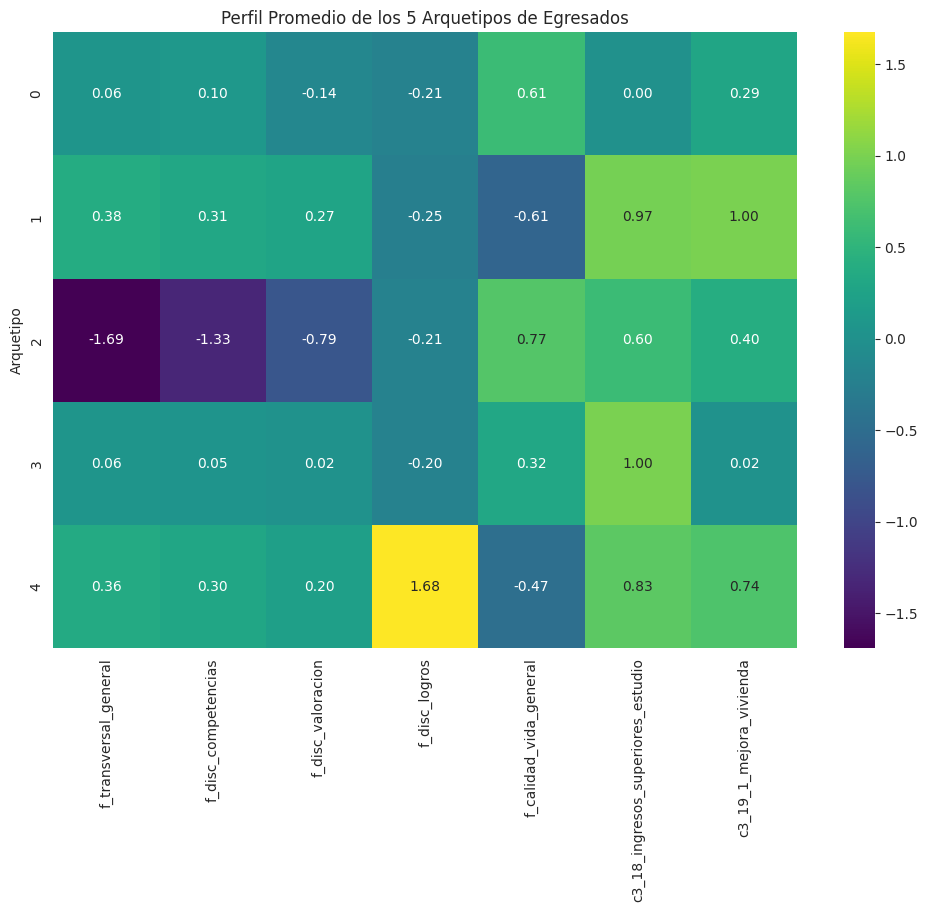

In [21]:
# --- PASO 4.2: ANÁLISIS DE CENTROIDES ---

# Seleccionamos las variables con las que se hizo el clustering
features_para_cluster = [
    'f_transversal_general', 'f_disc_competencias', 'f_disc_valoracion',
    'f_disc_logros', 'f_calidad_vida_general', 'c3_18_ingresos_superiores_estudio',
    'c3_19_1_mejora_vivienda'
]

# Calculamos los centroides (promedios por arquetipo)
df_centroides = df_analitico.groupby('arquetipo')[features_para_cluster].mean()

print("--- Perfil Promedio de cada Arquetipo (Centroides) ---")
display(df_centroides)

# --- Visualización con Mapa de Calor ---
plt.figure(figsize=(12, 8))
sns.heatmap(df_centroides, annot=True, cmap='viridis', fmt='.2f')
plt.title('Perfil Promedio de los 5 Arquetipos de Egresados')
plt.ylabel('Arquetipo')
plt.show()


--- Conteo de Egresados por Arquetipo ---


,count
arquetipo,
0,181
1,373
2,128
3,166
4,111


/tmp/ipykernel_278512/3417862377.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='arquetipo', data=df_analitico, palette='viridis')


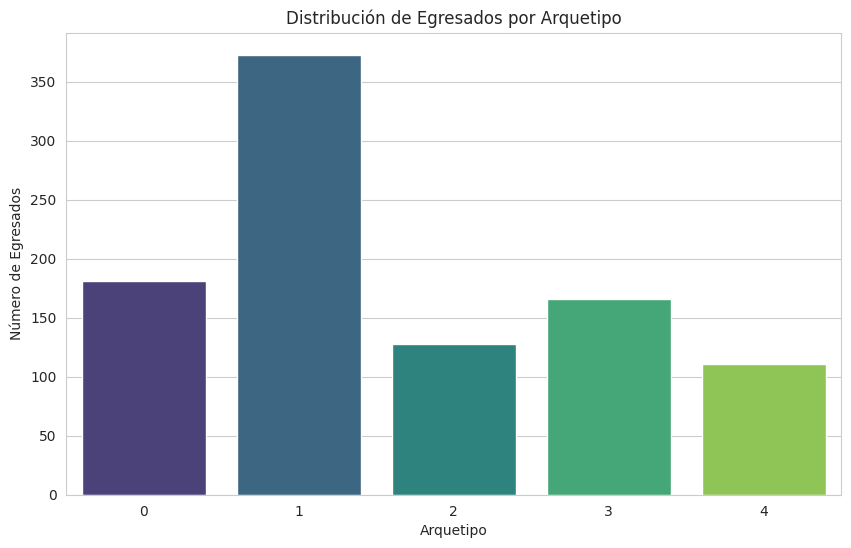

In [23]:
### Revisión de cluistering

### conteos

print("\n--- Conteo de Egresados por Arquetipo ---")
display(df_analitico['arquetipo'].value_counts().sort_index().to_frame())

### Diagrama de barras

plt.figure(figsize=(10, 6))
sns.countplot(x='arquetipo', data=df_analitico, palette='viridis')
plt.title('Distribución de Egresados por Arquetipo')
plt.xlabel('Arquetipo')
plt.ylabel('Número de Egresados')
plt.show()

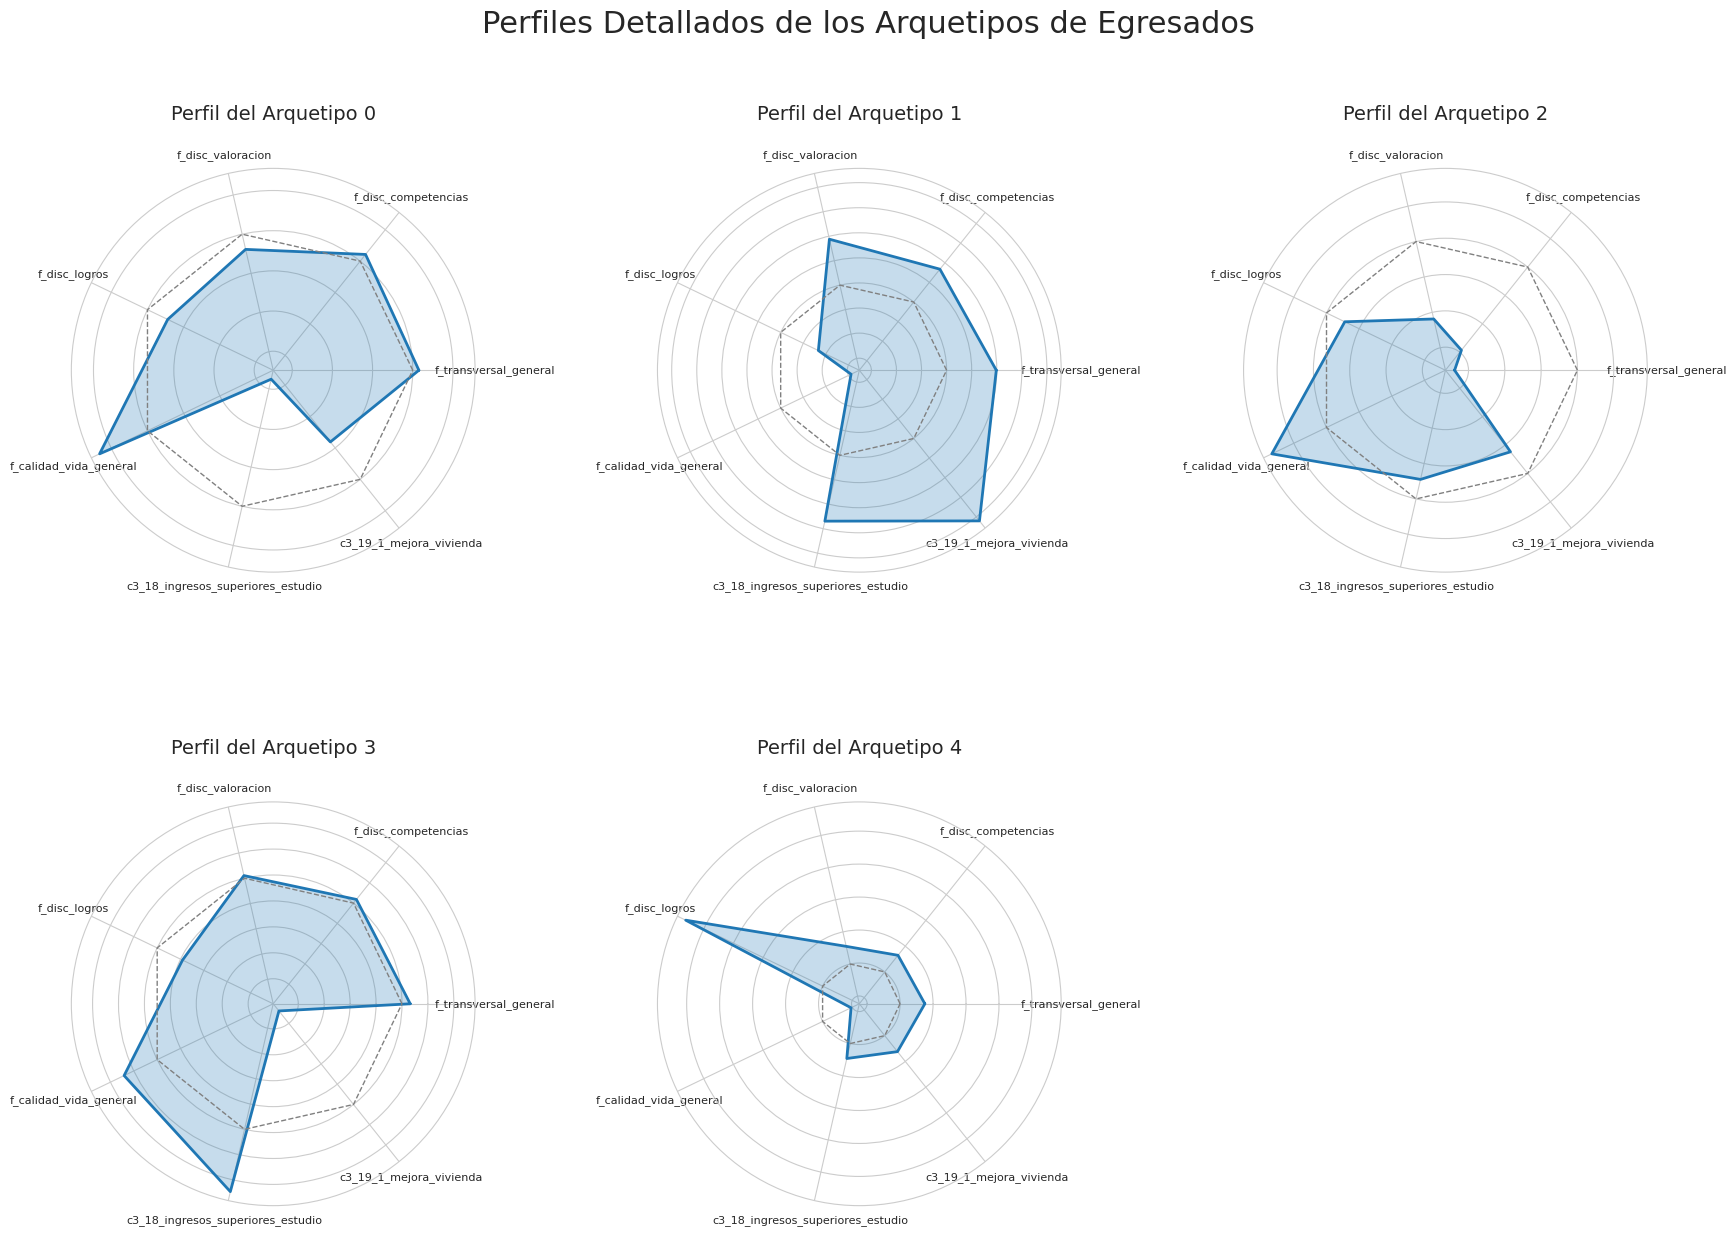

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Asumimos que 'kmeans_final' y 'features_para_cluster' ya existen.

# 1. OBTENCIÓN DE CENTROIDES ESCALADOS
centroides_escalados = kmeans_final.cluster_centers_
df_radar = pd.DataFrame(centroides_escalados, columns=features_para_cluster)

# 2. PREPARACIÓN DE LAS VARIABLES DEL GRÁFICO
labels = df_radar.columns
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Cerrar el círculo

# 3. CREACIÓN DE LA GRILLA DE GRÁFICOS
fig, axs = plt.subplots(2, 3, figsize=(18, 14), subplot_kw=dict(polar=True))
# Aplanar el array de ejes para iterar fácilmente
axs = axs.flatten()

# Iterar sobre cada arquetipo y su eje correspondiente
for i, ax in enumerate(axs):
    # Solo dibujar si el arquetipo existe (tenemos 5 arquetipos para 6 subplots)
    if i < len(df_radar):
        # Obtener los valores para el arquetipo actual y cerrar el círculo
        values = df_radar.iloc[i].tolist()
        values += values[:1]
        
        # Dibujar el área del polígono
        ax.fill(angles, values, alpha=0.25)
        # Dibujar la línea del perfil
        ax.plot(angles, values, linewidth=2, linestyle='solid')
        
        # --- Formateo de cada subplot ---
        # Dibujar la línea de referencia del promedio (cero)
        ax.plot(angles, [0] * (num_vars + 1), color='grey', linewidth=1, linestyle='--')
        
        # Ocultar las etiquetas del eje Y
        ax.set_yticklabels([])
        
        # Poner las etiquetas de las variables en los ejes
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(labels, size=8)
        
        # Añadir un título a cada subplot
        ax.set_title(f"Perfil del Arquetipo {i}", size=14, y=1.1)
        
    else:
        # Ocultar el último subplot que está vacío
        ax.set_visible(False)

plt.suptitle('Perfiles Detallados de los Arquetipos de Egresados', size=22, y=0.95)
plt.tight_layout(pad=3.0)
plt.show()

## Conclusiones Finales: Los Cinco Arquetipos del Egresado

Tras un exhaustivo proceso de preparación de datos, análisis factorial y modelado, el estudio ha logrado segmentar la población de egresados en **cinco perfiles o arquetipos** estadísticamente distintos y conceptualmente significativos. Este análisis de conglomerados nos permite trascender una visión unificada del "impacto" y comprender las diversas trayectorias y resultados que experimentan los profesionales formados en la institución. A continuación, se detalla cada arquetipo.

---
### **Arquetipo 1: El Profesional Exitoso y Crítico (373 egresados - 39%)**
Este es el grupo más numeroso y representa el pilar del mercado laboral. Son egresados que han alcanzado un éxito material incuestionable, pero que mantienen una perspectiva crítica sobre el impacto de su formación.

* **Características Clave:**
    * **Altas Competencias:** Presentan puntajes por encima del promedio en el desarrollo de competencias tanto transversales (`f_transversal_general` = 0.38) como disciplinares (`f_disc_competencias` = 0.31).
    * **Éxito Material Total:** Prácticamente el 100% de este grupo reporta haber mejorado su vivienda y el 97% haber aumentado sus ingresos.
    * **Baja Percepción de Impacto:** Paradójicamente, es uno de los grupos que reporta la menor percepción de impacto de la formación en su calidad de vida (`f_calidad_vida_general` = -0.61).
    * **Bajos Logros Formales:** Tienen el puntaje más bajo en logros concretos como liderar proyectos o recibir premios (`f_disc_logros` = -0.25).

---
### **Arquetipo 3: El Profesional en Transición (166 egresados - 17%)**
Este arquetipo representa a un grupo de egresados que ya ha logrado el primer gran hito de la movilidad social (el aumento de ingresos), pero que aún no lo ha materializado en otras áreas de su vida.

* **Características Clave:**
    * **Perfil Promedio:** Sus puntajes en todas las competencias y valoraciones son notablemente cercanos al promedio de la población (todos alrededor de 0).
    * **Mejora Universal de Ingresos:** El 100% de este grupo reporta tener ingresos superiores a los que tenía como estudiante.
    * **Mejora de Vivienda Nula:** De forma distintiva, casi ninguno (solo el 1.8%) ha mejorado su condición de vivienda.
    * **Percepción Positiva:** Su percepción de impacto en la calidad de vida es positiva, aunque moderada (`f_calidad_vida_general` = 0.32).

---
### **Arquetipo 0: El Subjetivamente Satisfecho (181 egresados - 19%)**
Este perfil es interesante porque su satisfacción no se correlaciona directamente con indicadores materiales. Valoran el impacto de su educación en términos de bienestar general, a pesar de no reportar mejoras económicas.

* **Características Clave:**
    * **Competencias en el Promedio:** Similar al Arquetipo 3, sus habilidades se encuentran en la media.
    * **Sin Mejora de Ingresos:** El rasgo más definitorio es que el 0% de este grupo reporta tener ingresos superiores a los de su época de estudiante.
    * **Alta Percepción de Calidad de Vida:** A pesar de lo anterior, tienen un puntaje positivo y alto en la percepción del impacto en su calidad de vida (`f_calidad_vida_general` = 0.61).

---
### **Arquetipo 4: El Líder de Alto Desempeño (111 egresados - 12%)**
Este grupo, aunque más pequeño, representa a la élite de los egresados en términos de logros y reconocimientos. Son profesionales altamente competentes que traducen sus habilidades en acciones y resultados tangibles.

* **Características Clave:**
    * **Puntaje Excepcional en Logros:** Su característica más destacada es un puntaje extremadamente alto en el factor de logros (`f_disc_logros` = 1.68), indicando que lideran proyectos, reciben premios y se vinculan a redes profesionales.
    * **Altas Competencias:** Al igual que el Arquetipo 1, poseen un alto desarrollo de competencias transversales y disciplinares.
    * **Éxito Material:** Una gran mayoría reporta mejora de ingresos (83%) y de vivienda (74%).
    * **Percepción Crítica:** Similar al Arquetipo 1, su percepción de impacto en la calidad de vida es negativa (`f_calidad_vida_general` = -0.47).

---
### **Arquetipo 2: El Egresado Agradecido (128 egresados - 13%)**
Este arquetipo muestra el mayor contraste. A pesar de reportar los niveles más bajos de competencias, son quienes sienten que la educación tuvo el impacto más positivo en sus vidas, sugiriendo un gran salto cualitativo desde su punto de partida.

* **Características Clave:**
    * **Competencias por Debajo del Promedio:** Presentan los puntajes más bajos en todas las dimensiones de competencias (ej. `f_transversal_general` = -1.69) y valoración del programa.
    * **La Más Alta Percepción de Impacto:** Paradójicamente, tienen el puntaje más alto de todos los grupos en la percepción de mejora en la calidad de vida (`f_calidad_vida_general` = 0.77).
    * **Movilidad Social Positiva:** A pesar de sus bajas competencias autopercibidas, una mayoría (60%) ha logrado aumentar sus ingresos.

### Implicaciones Finales

Este análisis de arquetipos proporciona a la institución una visión multidimensional del impacto de su formación. En lugar de una métrica única, ahora se cuenta con una segmentación estratégica que permite diseñar acciones diferenciadas: desde programas de apoyo para el "Profesional en Transición" hasta iniciativas de vinculación para potenciar a los "Líderes de Alto Desempeño" y comprender las necesidades del "Profesional Exitoso y Crítico".

In [30]:
df_analitico.index.name = 'index'
df_analitico.to_csv('../datos/df_analitico_con_arquetipos.csv', index=True)